# Sequential model evaluation

Refresh and rerun the cells while `sequential_training.ipynb` produces checkpoints.
The summary includes model NLL, empirical label NLL (the label entropy baseline), and normalized NLL (model NLL divided by the label baseline).

In [33]:
import json
import sys
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while not (repo_root / 'data_generation.py').exists():
    if repo_root.parent == repo_root:
        raise RuntimeError('Could not find repository root')
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))
from scratch import sequential_training as seq
artifact_candidates = [repo_root / 'scratch' / 'sequential_experiment', repo_root / 'scratch' / 'scratch' / 'sequential_experiment']
artifact_dir = next((path for path in artifact_candidates if path.exists()), artifact_candidates[0])
records = []
for path in sorted(artifact_dir.glob('m_*_evaluation.json')):
    records.append(json.loads(path.read_text()))
records.sort(key=lambda record: record['model_index'])
print(f'{len(records)} completed model evaluations')

def load_final_scores(model_index):
    dataset_path = artifact_dir / f'D_{model_index}.npz'
    if dataset_path.exists():
        return seq.load_sequential_dataset(dataset_path).final_scores
    shard_paths = sorted((artifact_dir / f'D_{model_index}').glob('D_*_batch*.npz'))
    if not shard_paths:
        raise FileNotFoundError(f'Could not find dataset for model {model_index}')
    return np.concatenate([seq.load_sequential_dataset(path).final_scores for path in shard_paths])


9 completed model evaluations


In [34]:
rows = []
for record in records:
    row = {'model': record['model_index'], 'dataset_size': record['dataset_size']}
    for metric, estimate in record['stats'].items():
        if isinstance(estimate, dict) and 'value' in estimate:
            row[metric] = estimate['value']
    labels = load_final_scores(record['model_index'])
    _, counts = np.unique(labels, return_counts=True)
    label_fractions = counts / counts.sum()
    row['label_nll'] = float(-np.sum(label_fractions * np.log(label_fractions)))
    row['normalized_nll'] = row['negative_log_probability'] / row['label_nll']
    rows.append(row)
pd.DataFrame(rows).sort_values('model', ascending=False)


,model,dataset_size,correct_score_probability,negative_log_probability,r_squared,label_nll,normalized_nll
8,9,2000,0.421801,1.118169,0.533877,1.524608,0.733414
7,8,2000,0.393214,1.103205,0.296452,1.301680,0.847524
6,7,2000,0.328518,1.250440,0.099153,1.295043,0.965559
5,6,2000,0.422854,0.977192,0.170031,1.080044,0.904771
4,5,2000,0.381923,1.033242,0.065638,1.063674,0.971390
3,4,2000,0.499888,0.778331,0.037038,0.795507,0.978409
2,3,2000,0.556149,0.665417,0.094493,0.715805,0.929607
1,2,2000,0.773330,0.377512,0.061209,0.405788,0.930320
0,1,2000,0.604705,0.589617,-0.000002,0.583351,1.010741


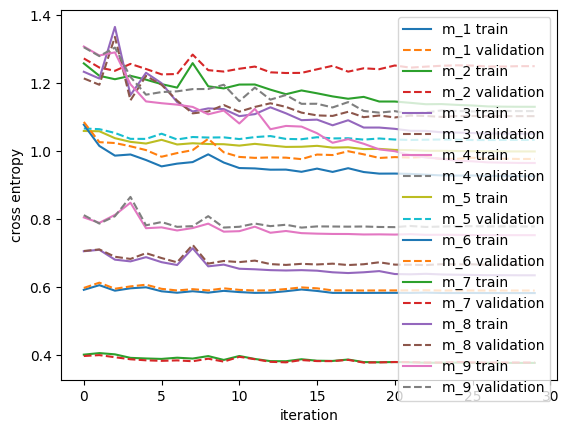

In [35]:
for record in records:
    model = record['model_index']
    training = record['training']
    plt.plot(training['train_loss'], label=f'm_{model} train')
    plt.plot(training['validation_loss'], '--', label=f'm_{model} validation')
plt.xlabel('iteration')
plt.ylabel('cross entropy')
plt.legend()
plt.show()


In [37]:
# Calibration for the selected checkpoint. Change this to inspect another model.
record = records[-1]
calibration = pd.DataFrame(record['stats']['calibration'])
calibration[['lower_bound', 'upper_bound', 'count', 'predicted_fraction', 'actual_fraction']]


,lower_bound,upper_bound,count,predicted_fraction,actual_fraction
0,0.0,0.1,18000,0.000031,0.000056
1,0.1,0.2,0,NaN,NaN
2,0.2,0.3,2000,0.270144,0.271000
3,0.3,0.4,0,NaN,NaN
4,0.4,0.5,0,NaN,NaN
5,0.5,0.6,0,NaN,NaN
6,0.6,0.7,0,NaN,NaN
7,0.7,0.8,2000,0.729576,0.728500
8,0.8,0.9,0,NaN,NaN
9,0.9,1.0,0,NaN,NaN
